In [38]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [39]:
CONTINUOUS_CONFIG = [
    (10, 20, 0.10),
    (20, 32, 0.50),
    (32, 45, 0.20),
    (45, 75, 0.15),
    (75, 85, 0.05),
]

DISC_CONFIG = [
    (15, 28, 0.20),
    (29, 44, 0.40),
    (45, 65, 0.40),
]


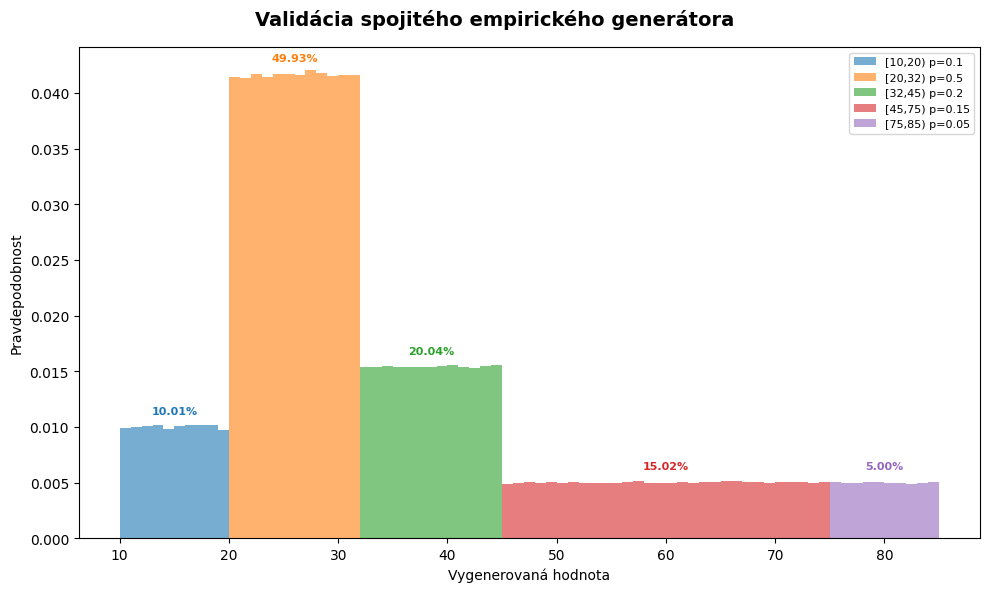

In [48]:
plt.style.use('default') # generate chart in white style
cont_values = pd.read_csv('continuous_empiric_generator_output.csv')["value"]

n = len(cont_values)
observed_probabilities = [
    ((cont_values >= l) & (cont_values < u)).mean()
    for l, u, _ in CONTINUOUS_CONFIG
]

colors = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Validácia spojitého empirického generátora", fontsize=14, fontweight="bold")

# Create bars
counts, bin_edges = np.histogram(cont_values.to_numpy(), bins=75, density=True)
for j, (left, right, count) in enumerate(zip(bin_edges[:-1], bin_edges[1:], counts)):
    mid = (left + right) / 2
    bar_color = "gray"
    # Get color for the given bar
    for i, (lower_bound, upper_bound, _) in enumerate(CONTINUOUS_CONFIG):
        if lower_bound <= mid < upper_bound:
            bar_color = colors[i % len(colors)]
            break
    ax.bar(left, count, width=(right - left), align="edge", color=bar_color, alpha=0.6, edgecolor="none")

# add observed probabilities to chart
for i, ((lower_bound, upper_bound, prob), obs) in enumerate(zip(CONTINUOUS_CONFIG, observed_probabilities)):
    color = colors[i % len(colors)]
    width = upper_bound - lower_bound
    height = prob / width
    mid_x = (lower_bound + upper_bound) / 2
    ax.text(mid_x, height + 0.001, f"{obs:.2%}",
            ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

ax.set_xlabel("Vygenerovaná hodnota")
ax.set_ylabel("Pravdepodobnost")

cont_legend_handles = [
    mpatches.Patch(facecolor=colors[i % len(colors)], alpha=0.6,
                   label=f"[{lb},{ub}) p={p}")
    for i, (lb, ub, p) in enumerate(CONTINUOUS_CONFIG)
]
ax.legend(handles=cont_legend_handles, fontsize=8)

plt.tight_layout()
fig.savefig('continuous_validation.png', dpi=150)
plt.show()

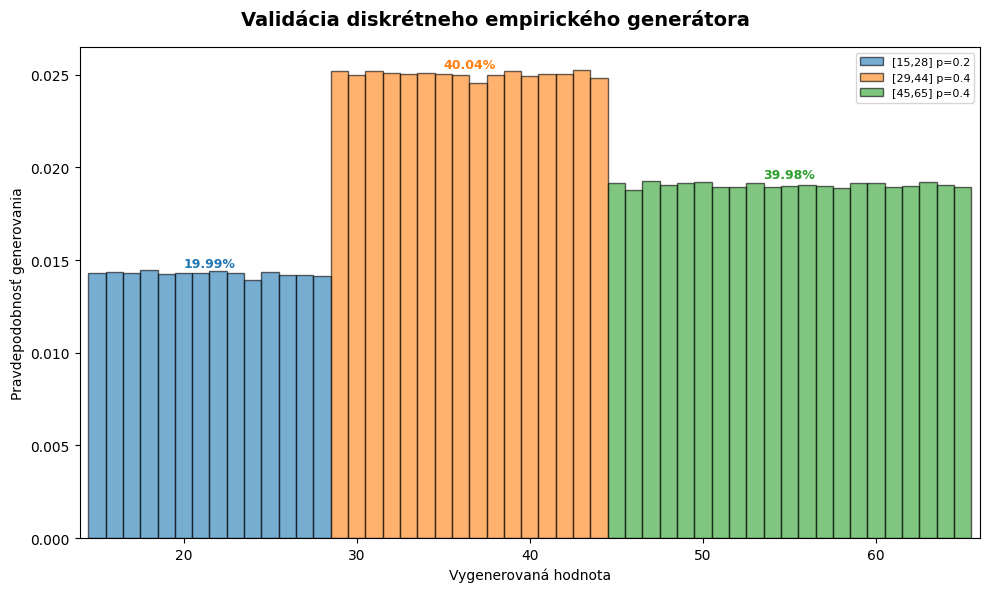

In [47]:
plt.style.use('default') # generate chart in white style
disc_values = pd.read_csv('discrete_empiric_generator_output.csv')["value"]

vmin = int(disc_values.min())
vmax = int(disc_values.max())
xs = np.arange(vmin, vmax + 1)

counts = disc_values.value_counts().reindex(xs, fill_value=0).sort_index()
obs_probs = counts / len(disc_values)

colors = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Validácia diskrétneho empirického generátora", fontsize=14, fontweight="bold")

bar_colors = [
    next(
        (colors[i % len(colors)]
         for i, (lb, ub, _) in enumerate(DISC_CONFIG)
         if lb <= x <= ub),
        "gray"
    )
    for x in xs
]

ax.bar(xs, obs_probs, width=1.0, alpha=0.6, edgecolor="black", color=bar_colors)

legend_items = [
    mpatches.Patch(facecolor=colors[i % len(colors)], alpha=0.6, edgecolor="black",
                   label=f"[{lb},{ub}] p={p}")
    for i, (lb, ub, p) in enumerate(DISC_CONFIG)
]
ax.legend(handles=legend_items, fontsize=8)

# add observed probability
for i, (lb, ub, p) in enumerate(DISC_CONFIG):
    c = colors[i % len(colors)]
    width = ub - lb + 1
    per_value = p / width
    center = (lb + ub) / 2
    p_obs_total = disc_values.between(lb, ub).mean()

    ax.text(center,
            per_value + 0.0002,
            f"{p_obs_total:.2%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=c)

ax.set_xlabel("Vygenerovaná hodnota")
ax.set_ylabel("Pravdepodobnosť generovania")
ax.set_xlim(vmin - 1, vmax + 1)

plt.tight_layout()
fig.savefig("discrete_validation.png", dpi=150)
plt.show()